In [1]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [2]:
PROJECT = Path.cwd().parents[2]
TOMTOM_DIR_GRAPH = PROJECT / 'data' / "raw" / 'tomtom_stats' / 'graphs'
TOMTOM_DIR_TIMES = PROJECT / 'data' / "raw" / 'tomtom_stats' / 'times'
EDGES_PATH    = TOMTOM_DIR_GRAPH / "edges.csv"      # có segment_u, segment_v
SEGMENTS_PATH = TOMTOM_DIR_GRAPH / "segments.csv"   # có segment_id, frc, ...
edges_csv            = pd.read_csv(TOMTOM_DIR_GRAPH / "edges.csv",            encoding="utf-8")
node_csv             = pd.read_csv(TOMTOM_DIR_GRAPH / "node.csv",             encoding="utf-8")
segment_index_csv    = pd.read_csv(TOMTOM_DIR_GRAPH / "segment_index.csv",    encoding="utf-8")
segments_csv         = pd.read_csv(TOMTOM_DIR_GRAPH / "segments.csv",         encoding="utf-8")

observation_csv       = pd.read_csv(TOMTOM_DIR_TIMES / "observations.csv",       encoding="utf-8")
OUTPUT_DIR = PROJECT / 'data' / 'processed' / 'tomtom_stats'
os.makedirs(OUTPUT_DIR, exist_ok=True)

CONGESTION_TTR_THRESHOLD = 1.3


In [3]:
#Loại bỏ các tuyến có trong observation nhưng không có trong segments
seg_all = set(segments_csv['segment_id'])
seg_obs = set(observation_csv['segment_id'])
print(len(seg_obs))
print(len(seg_all))
valid_ids = seg_all & seg_obs   # chỉ giữ những id có ở cả hai
print(len(valid_ids))
segments_csv = segments_csv[segments_csv['segment_id'].isin(valid_ids)].copy()
observation_csv = observation_csv[observation_csv['segment_id'].isin(valid_ids)].copy()


10637
10455
10455


## Sanity check of data

In [4]:
def sanity_check(df, name):
    print(f"--- {name} ---")
    print("shape:", df.shape)

    print("\nNull values per column:")
    print(df.isnull().sum().to_string())

    print("\nDuplicated rows:", df.duplicated().sum())

def object_values_counts(df):
    for i in df.select_dtypes(include="object").columns:
        print(df[i].value_counts())
        print("***"*10)
def number_values_counts(df):
    for i in df.select_dtypes(include="number").columns:
        print(df[i].value_counts())
        print("***"*10)

In [5]:
segments_csv.info()
sanity_check(segment_index_csv, "segments")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10455 entries, 0 to 10454
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   segment_id  10455 non-null  int64  
 1   node_u      10455 non-null  int64  
 2   node_v      10455 non-null  int64  
 3   streetName  9632 non-null   object 
 4   frc         10455 non-null  int64  
 5   speedLimit  10455 non-null  int64  
 6   distance    10455 non-null  float64
dtypes: float64(1), int64(5), object(1)
memory usage: 571.9+ KB
--- segments ---
shape: (10455, 2)

Null values per column:
idx           0
segment_id    0

Duplicated rows: 0


In [6]:
segments = segments_csv.copy()
segments['streetName'] = segments['streetName'].fillna("")


In [7]:
edges_csv.info()
sanity_check(edges_csv, "edges")
valid_ids = set(segments['segment_id'])
edges = edges_csv[
    edges_csv['segment_u'].isin(valid_ids) &
    edges_csv['segment_v'].isin(valid_ids)
].copy()
edges = edges[edges['segment_u'] != edges['segment_v']]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33342 entries, 0 to 33341
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   segment_u  33342 non-null  int64
 1   segment_v  33342 non-null  int64
dtypes: int64(2)
memory usage: 521.1 KB
--- edges ---
shape: (33342, 2)

Null values per column:
segment_u    0
segment_v    0

Duplicated rows: 0


In [8]:
segment_index_csv.info()
sanity_check(segment_index_csv, "segments")
seg_index = segment_index_csv.copy()
seg_index = seg_index.sort_values('idx')
id2idx = dict(zip(seg_index['segment_id'], seg_index['idx']))
idx2id = dict(zip(seg_index['idx'], seg_index['segment_id']))

edge_index = np.vstack([
    edges['segment_u'].map(id2idx).values,
    edges['segment_v'].map(id2idx).values
])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10455 entries, 0 to 10454
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   idx         10455 non-null  int64
 1   segment_id  10455 non-null  int64
dtypes: int64(2)
memory usage: 163.5 KB
--- segments ---
shape: (10455, 2)

Null values per column:
idx           0
segment_id    0

Duplicated rows: 0


In [9]:
node_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5412 entries, 0 to 5411
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   node_id         5412 non-null   int64  
 1   lat             5412 non-null   float64
 2   lon             5412 non-null   float64
 3   segments_count  5412 non-null   int64  
dtypes: float64(2), int64(2)
memory usage: 169.2 KB


In [10]:
sanity_check(node_csv, "nodes")

--- nodes ---
shape: (5412, 4)

Null values per column:
node_id           0
lat               0
lon               0
segments_count    0

Duplicated rows: 0


In [11]:
segment_index_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10455 entries, 0 to 10454
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   idx         10455 non-null  int64
 1   segment_id  10455 non-null  int64
dtypes: int64(2)
memory usage: 163.5 KB


In [12]:
sanity_check(segments_csv, "segments")

--- segments ---
shape: (10455, 7)

Null values per column:
segment_id      0
node_u          0
node_v          0
streetName    823
frc             0
speedLimit      0
distance        0

Duplicated rows: 0


In [13]:
number_values_counts(segments_csv)

segment_id
 17040035034471    1
-17040019559514    1
-17040019282670    1
-17040018864243    1
-17040020088759    1
                  ..
-17040020360646    1
-17040018851826    1
-17040021918841    1
-17040020018849    1
-17040019795667    1
Name: count, Length: 10455, dtype: int64
******************************
node_u
1181    5
11      5
803     4
2165    4
131     4
       ..
5385    1
4303    1
4305    1
4995    1
5338    1
Name: count, Length: 5389, dtype: int64
******************************
node_v
1181    5
11      5
3955    4
222     4
1254    4
       ..
4339    1
4341    1
5273    1
4345    1
4861    1
Name: count, Length: 5385, dtype: int64
******************************
frc
7    5165
6    2755
2     966
4     920
3     649
Name: count, dtype: int64
******************************
speedLimit
30    5706
50    3619
18     515
20     182
60      76
40      49
80      37
24      37
26      21
23      21
22      20
25      19
27      19
21      17
19      15
29      13
47      12
4

In [14]:
observation_csv.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5520240 entries, 0 to 5616335
Data columns (total 24 columns):
 #   Column                Dtype  
---  ------                -----  
 0   date                  object 
 1   day_of_week           object 
 2   time_set_id           int64  
 3   time_start            object 
 4   time_end              object 
 5   segment_id            int64  
 6   newSegmentId          object 
 7   streetName            object 
 8   frc                   int64  
 9   speedLimit            int64  
 10  distance              float64
 11  sampleSize            int64  
 12  averageSpeed          float64
 13  medianSpeed           float64
 14  harmonicAverageSpeed  float64
 15  averageTravelTime     float64
 16  medianTravelTime      float64
 17  travelTimeRatio       float64
 18  p05                   int64  
 19  p25                   int64  
 20  p50                   int64  
 21  p75                   int64  
 22  p95                   int64  
 23  is_observed 

In [15]:
sanity_check(observation_csv, "observations")

--- observations ---
shape: (5520240, 24)

Null values per column:
date                         0
day_of_week                  0
time_set_id                  0
time_start                   0
time_end                     0
segment_id                   0
newSegmentId                 0
streetName              434544
frc                          0
speedLimit                   0
distance                     0
sampleSize                   0
averageSpeed                 0
medianSpeed                  0
harmonicAverageSpeed         0
averageTravelTime            0
medianTravelTime             0
travelTimeRatio              0
p05                          0
p25                          0
p50                          0
p75                          0
p95                          0
is_observed                  0

Duplicated rows: 0


In [16]:
number_values_counts(observation_csv)

time_set_id
2     230010
3     230010
4     230010
5     230010
6     230010
7     230010
8     230010
9     230010
10    230010
11    230010
12    230010
13    230010
14    230010
15    230010
16    230010
17    230010
18    230010
19    230010
20    230010
21    230010
22    230010
23    230010
24    230010
25    230010
Name: count, dtype: int64
******************************
segment_id
 17040035034471    528
-17040019559514    528
-17040019282670    528
-17040018864243    528
-17040020088759    528
                  ... 
-17040020360646    528
-17040018851826    528
-17040021918841    528
-17040020018849    528
-17040019795667    528
Name: count, Length: 10455, dtype: int64
******************************
frc
7    2727120
6    1454640
2     510048
4     485760
3     342672
Name: count, dtype: int64
******************************
speedLimit
30    3012768
50    1910832
18     271920
20      96096
60      40128
40      25872
80      19536
24      19536
26      11088
23      11088
22    

## Exploratory data

In [17]:


tab = (
    observation_csv.groupby(['frc', 'is_observed'])
       .size()
       .unstack(fill_value=0)  # cột 0,1
       .rename(columns={0: 'not_observed', 1: 'observed'})
)

tab['total'] = tab['observed'] + tab['not_observed']
tab['obs_rate'] = tab['observed'] / tab['total']

print(tab)


is_observed  not_observed  observed    total  obs_rate
frc                                                   
2                     330    509718   510048  0.999353
3                      44    342628   342672  0.999872
4                   10362    475398   485760  0.978668
6                   57354   1397286  1454640  0.960572
7                 1243748   1483372  2727120  0.543934


In [18]:

# --- 1. Thống kê theo segment_id ---
seg_obs = (
    observation_csv
    .groupby(['segment_id', 'frc'])['is_observed']
    .agg(total='size', observed='sum')
    .reset_index()
)

seg_obs['not_observed'] = seg_obs['total'] - seg_obs['observed']
seg_obs['obs_rate'] = seg_obs['observed'] / seg_obs['total']

# join thêm thông tin tên đường, speedLimit, distance
seg_obs_detail = seg_obs.merge(
    segments_csv[['segment_id', 'streetName', 'speedLimit', 'distance']],
    on='segment_id',
    how='left'
)

# các tuyến đường ít được quan sát nhất (not_observed nhiều nhất, obs_rate thấp)
TOP_K = 20
worst_segments = (
    seg_obs_detail
    .sort_values(['not_observed', 'obs_rate'], ascending=[False, True])
    .head(TOP_K)
)

print("🔎 TOP các tuyến đường ít được quan sát nhất:")
print(
    worst_segments[
        ['segment_id', 'streetName', 'frc',
         'total', 'observed', 'not_observed', 'obs_rate',
         'speedLimit', 'distance']
    ]
)


🔎 TOP các tuyến đường ít được quan sát nhất:
         segment_id                    streetName  frc  total  observed  \
2   -17040035685549                           NaN    7    528         0   
3   -17040035685538       Hẻm 57/55 Điện Biên Phủ    7    528         0   
4   -17040035685532        Hẻm 2 Bến Chương Dương    7    528         0   
5   -17040035685190                           NaN    7    528         0   
6   -17040035685011                           NaN    7    528         0   
7   -17040035684074         Hẻm 107/26 Ngô Tất Tố    7    528         0   
8   -17040035684045         Hẻm 107/26 Ngô Tất Tố    7    528         0   
10  -17040035680507                  Đường Số 12A    7    528         0   
11  -17040035680390             Đường Đoàn Văn Bơ    7    528         0   
13  -17040035679925             Đường Đoàn Văn Bơ    7    528         0   
18  -17040035675881                           NaN    7    528         0   
38  -17040035666608    Hẻm Số 5 Nguyễn Trung Ngạn    7 

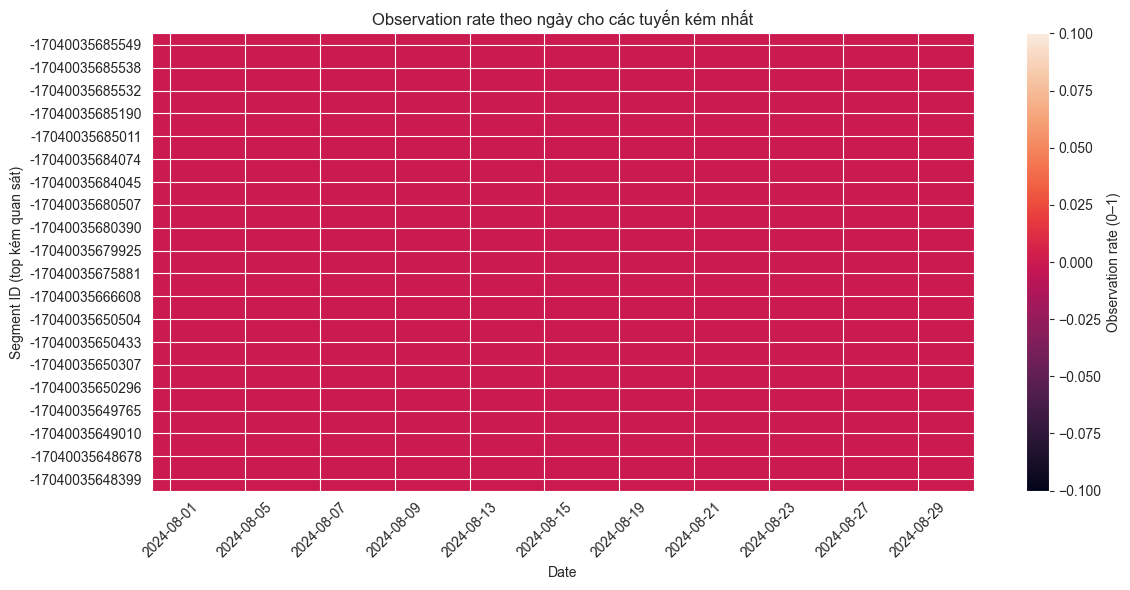

In [19]:
# lấy danh sách segment “tệ” nhất
bad_ids = worst_segments['segment_id'].unique()

tmp = observation_csv[observation_csv['segment_id'].isin(bad_ids)].copy()

# thống kê theo segment_id, date
daily = (
    tmp
    .groupby(['segment_id', 'date'])['is_observed']
    .agg(observed='sum', total='size')
    .reset_index()
)
daily['obs_rate'] = daily['observed'] / daily['total']

# pivot ra matrix: rows = segment_id, cols = date
pivot_daily = daily.pivot(index='segment_id', columns='date', values='obs_rate')

plt.figure(figsize=(12, 6))
im = plt.imshow(pivot_daily.values, aspect='auto', interpolation='nearest')
plt.colorbar(im, label='Observation rate (0–1)')

plt.yticks(
    range(len(pivot_daily.index)),
    [str(sid) for sid in pivot_daily.index]
)
# chỉ hiện 1 số ngày cho đỡ rối
xticks_idx = np.arange(0, len(pivot_daily.columns), max(1, len(pivot_daily.columns)//10))
plt.xticks(
    xticks_idx,
    [str(pivot_daily.columns[i]) for i in xticks_idx],
    rotation=45
)

plt.xlabel("Date")
plt.ylabel("Segment ID (top kém quan sát)")
plt.title("Observation rate theo ngày cho các tuyến kém nhất")
plt.tight_layout()
plt.show()


Ví dụ xem chi tiết segment: -17040035685549


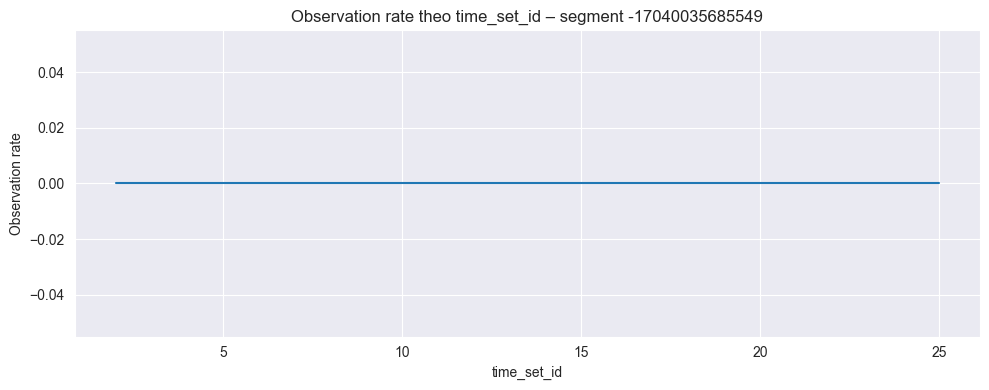

In [20]:
# chọn 1 segment kém nhất để xem chi tiết
example_segment = worst_segments.iloc[0]['segment_id']
print("Ví dụ xem chi tiết segment:", example_segment)

seg_tmp = observation_csv[observation_csv['segment_id'] == example_segment].copy()

by_time = (
    seg_tmp
    .groupby('time_set_id')['is_observed']
    .agg(observed='sum', total='size')
    .reset_index()
)
by_time['obs_rate'] = by_time['observed'] / by_time['total']

plt.figure(figsize=(10,4))
plt.plot(by_time['time_set_id'], by_time['obs_rate'])
plt.xlabel("time_set_id")
plt.ylabel("Observation rate")
plt.title(f"Observation rate theo time_set_id – segment {example_segment}")
plt.grid(True)
plt.tight_layout()
plt.show()


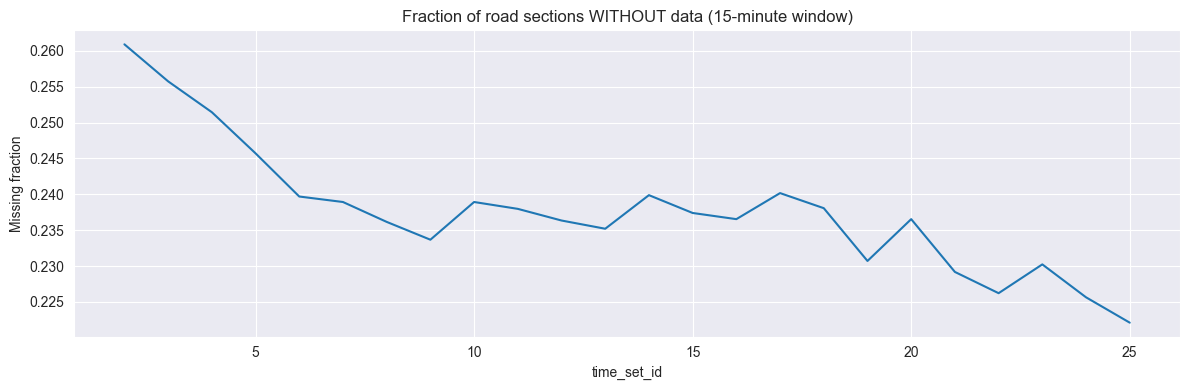

Trung bình: 0.23764147935597002
Min: 0.2220946915351506
Max: 0.2609277857484458


In [21]:
all_segments = segments_csv['segment_id'].unique()
N = len(all_segments)
obs_by_time = (observation_csv[observation_csv['is_observed'] == 1].groupby('time_set_id')['segment_id'].nunique().reset_index(name='observed_segments'))

obs_by_time['missing_rate'] = 1 - obs_by_time['observed_segments'] / N
plt.figure(figsize=(12,4))
plt.plot(obs_by_time['time_set_id'], obs_by_time['missing_rate'])
plt.title("Fraction of road sections WITHOUT data (15-minute window)")
plt.xlabel("time_set_id")
plt.ylabel("Missing fraction")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Trung bình:", obs_by_time['missing_rate'].mean())
print("Min:", obs_by_time['missing_rate'].min())
print("Max:", obs_by_time['missing_rate'].max())

In [22]:
seg_stats = (
    observation_csv
    .groupby('segment_id')['is_observed']
    .agg(
        obs_count='sum',  # số lần is_observed == 1
        total='size'  # tổng số bản ghi của segment đó
    )
    .reset_index()
)

# Tỷ lệ được quan sát trên tổng thời gian
seg_stats['obs_ratio'] = seg_stats['obs_count'] / seg_stats['total']

# những FRC7 nào có >= 80% thời gian KHÔNG được quan sát (tức obs_ratio <= 0.2) thì bỏ

frc7_segments = segments_csv[segments_csv['frc'] == 7]['segment_id']

# Thống kê cho riêng các segment FRC7
frc7_stats = seg_stats[seg_stats['segment_id'].isin(frc7_segments)]

# Giữ lại những FRC7 có tỷ lệ OBSERVED > 20%
frc7_kept = frc7_stats[frc7_stats['obs_ratio'] > 0.3]['segment_id']

print("Số segment FRC7 ban đầu:", len(frc7_segments))
print("Số segment FRC7 được giữ lại:", len(frc7_kept))
print("Số segment FRC7 bị loại (>=80% time không quan sát):", len(frc7_segments) - len(frc7_kept))

non_frc7_kept = segments_csv[segments_csv['frc'] != 7]['segment_id']

valid_segments = pd.concat(
    [non_frc7_kept, frc7_kept],
    ignore_index=True
)

# Lọc observation theo danh sách segment hợp lệ
obs_filtered = observation_csv[observation_csv['segment_id'].isin(valid_segments)].copy()
total_segments = obs_filtered['segment_id'].nunique()
print("Total segments sau khi lọc:", total_segments)


Số segment FRC7 ban đầu: 5165
Số segment FRC7 được giữ lại: 2944
Số segment FRC7 bị loại (>=80% time không quan sát): 2221
Total segments sau khi lọc: 8234


In [23]:


tab = (
    obs_filtered.groupby(['frc', 'is_observed'])
       .size()
       .unstack(fill_value=0)  # cột 0,1
       .rename(columns={0: 'not_observed', 1: 'observed'})
)

tab['total'] = tab['observed'] + tab['not_observed']
tab['obs_rate'] = tab['observed'] / tab['total']

print(tab)

is_observed  not_observed  observed    total  obs_rate
frc                                                   
2                     330    509718   510048  0.999353
3                      44    342628   342672  0.999872
4                   10362    475398   485760  0.978668
6                   57354   1397286  1454640  0.960572
7                  106854   1447578  1554432  0.931258


In [24]:
obs_filtered.loc[obs_filtered['is_observed'] == 0, 'averageSpeed'] = np.nan
print("Số NaN trong averageSpeed sau khi gán:", obs_filtered['averageSpeed'].isna().sum())
print(obs_filtered.shape)
print(obs_filtered.columns)

Số NaN trong averageSpeed sau khi gán: 174944
(4347552, 24)
Index(['date', 'day_of_week', 'time_set_id', 'time_start', 'time_end',
       'segment_id', 'newSegmentId', 'streetName', 'frc', 'speedLimit',
       'distance', 'sampleSize', 'averageSpeed', 'medianSpeed',
       'harmonicAverageSpeed', 'averageTravelTime', 'medianTravelTime',
       'travelTimeRatio', 'p05', 'p25', 'p50', 'p75', 'p95', 'is_observed'],
      dtype='object')


In [25]:
# =============================================================
# STEP 0 — Tạo pivot_df_temporal đầy đủ để dùng cho normalization
# =============================================================

# obs_filtered phải có 4 cột:
# ["date", "time_set_id", "segment_id", "averageSpeed"]
obs_filtered["date"] = pd.to_datetime(obs_filtered["date"])
obs_df  = obs_filtered.sort_values(["date", "time_set_id","segment_id"])
segment_ids = sorted(segments_csv["segment_id"].unique().tolist())

pivot_speed  = obs_df .pivot_table(
    index=["date", "time_set_id"],
    columns="segment_id",
    values="averageSpeed",
    aggfunc="mean"
).sort_index()
pivot_ttr = obs_df.pivot_table(
    index=["date","time_set_id"],
    columns="segment_id",
    values="travelTimeRatio",
    aggfunc="mean"
).reindex(index=pivot_speed.index).sort_index()

print("[INFO] pivot_df shape =", pivot_speed .shape)

#Đồng bộ cột
pivot_speed = pivot_speed.reindex(columns=segment_ids)
pivot_ttr   = pivot_ttr.reindex(columns=segment_ids)

# -------------------------------------------------------------
# Temporal interpolation (fill toàn bộ time-series trước khi normalize)
# -------------------------------------------------------------
speed_interp = pivot_speed.copy()
ttr_interp   = pivot_ttr.copy()

for seg in segment_ids:
    speed_interp[seg] = (
        speed_interp[seg].interpolate(limit_direction="both")
                         .fillna(method="ffill")
                         .fillna(method="bfill")
    )
    ttr_interp[seg] = (
        ttr_interp[seg].interpolate(limit_direction="both")
                       .fillna(method="ffill")
                       .fillna(method="bfill")
    )



[INFO] pivot_df shape = (528, 8222)


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_27740\2636076668.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  speed_interp[seg].interpolate(limit_direction="both")
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_27740\2636076668.py:43: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ttr_interp[seg].interpolate(limit_direction="both")


In [26]:
# =============================================================
# GLOBAL Z-SCORE (CHO TOÀN MẠNG LƯỚI TẠI MỖI TIME SLOT)
# =============================================================
import numpy as np
import pandas as pd

#Loại bỏ nhiễu hệ thống
df_tmp = speed_interp.reset_index()
meta_time = df_tmp[["date","time_set_id"]]
speed_values = df_tmp.drop(columns=["date","time_set_id"])
slots = df_tmp["time_set_id"].values

zspeed = speed_values.copy()

for slot in np.unique(slots):
    mask = (slots == slot)
    block = speed_values.loc[mask,:].values.flatten()
    block = block[~np.isnan(block)]

    if len(block) == 0:
        continue

    mu = block.mean()
    sigma = block.std() if block.std() > 1e-6 else 1e-6

    zspeed.loc[mask,:] = (speed_values.loc[mask,:] - mu) / sigma

zspeed = zspeed.fillna(0.0)



## Tạo nhãn is_congested

In [27]:
ttr_values = ttr_interp.values.astype("float32")

is_congested = np.where(
    np.isnan(ttr_values),
    0,
    (ttr_values >= CONGESTION_TTR_THRESHOLD).astype("int8")
)
valid_mask = ~np.isnan(ttr_values)
congestion_ratio = is_congested[valid_mask].sum() / valid_mask.sum()
print("Tỉ lệ kẹt:", congestion_ratio)



Tỉ lệ kẹt: 0.23732896121771516


## Tạo temporal meta

In [28]:
dates = meta_time["date"].dt.strftime("%Y-%m-%d").values
time_set_id = meta_time["time_set_id"].values
tod_minutes = []
dow_list = []
df_tsid_start = obs_df.copy()
tsid_to_start = (
    df_tsid_start.loc[df_tsid_start["time_start"].notna(), ["time_set_id", "time_start"]]
      .drop_duplicates("time_set_id")
      .set_index("time_set_id")["time_start"]
      .to_dict()
)
for dt, tsid in meta_time.values:
    # Lấy time_start từ mapping JSON
    tstr = tsid_to_start.get(int(tsid))

    if isinstance(tstr, str) and ":" in tstr:
        hh, mm = map(int, tstr.split(":"))
        tod_minutes.append(hh * 60 + mm)
    else:
        # fallback nếu thiếu time_range (hiếm)
        tod_minutes.append(0)

    # Day-of-week
    dow_list.append(pd.to_datetime(dt).weekday())
time_of_day = np.array(tod_minutes, dtype=np.float32) / 1440.0   # [0,1]
day_of_week = np.array(dow_list, dtype=np.int64)                 # 0..6

## Xuất traffic_clean.parquet

In [29]:
clean_df = pd.concat(
    [pd.DataFrame({
        "date": dates,
        "time_set_id": time_set_id,
        "time_of_day_minutes": tod_minutes,
        "day_of_week": dow_list
    }), zspeed],
    axis=1
)

clean_df.to_pickle(OUTPUT_DIR / "traffic_clean.pkl")
print("Saved traffic_clean.pkl")


Saved traffic_clean.pkl


## Xuất traffic_tensor.npz

In [30]:
np.savez_compressed(
    OUTPUT_DIR / "traffic_tensor.npz",
    values=zspeed.values.astype("float32"),
    is_congested=is_congested.astype("int8"),
    segment_ids=np.array(segment_ids, dtype="int64"),
    dates=dates,
    time_set_id=time_set_id.astype("int32"),
    time_of_day=time_of_day,
    day_of_week=day_of_week,
    congestion_threshold=np.array([CONGESTION_TTR_THRESHOLD], dtype="float32")
)

print("Saved traffic_tensor.npz")


Saved traffic_tensor.npz


In [31]:
segments_csv.to_csv(OUTPUT_DIR / "segments.csv", index=False)
node_csv.to_csv(OUTPUT_DIR / "nodes.csv", index=False)
edges_csv.to_csv(OUTPUT_DIR / "edges.csv", index=False)
segment_index_csv.to_csv(OUTPUT_DIR / "segment_index.csv", index=False)


print("Saved graph files (segments, nodes, edges, segment_index)")


Saved graph files (segments, nodes, edges, segment_index)
